<a href="https://colab.research.google.com/github/cyeef/Data-Science-Portfolio-C21-/blob/main/Capstone/Rural-Health-Access/Regional_Hospital_Spatial_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The quick and easy

New Mexico needs hospital resources in rural areas.  At the county level we are predicting short-term general hospital beds per 1000 residents - the gap between capacity a county needs and the capacity it actually has indicates where state health investments should be placed.

# Problem Statement — Rural NM Hospital Access

New Mexico is the 5th largest state in the Union by land area. Rural communities
are underserved medically, clinically, and diagnostically. Many citizens — both
Native and non-Native — in rural communities must travel hours to reach the
closest health center.

The goal of this project is to use county-level structured data to identify where
financial resources can be directed to reduce medical care gaps in rural NM.

The model estimates healthcare capacity [target: physicians per capita / beds per
capita / composite capacity score — TBD] from need drivers (population, age
structure, poverty, chronic disease burden, distance to nearest medical center).
The gap between observed capacity and the capacity a county's need predicts — the
residual — serves as a provision-vs-need mismatch signal. Counties with the
largest shortfalls surface as priorities for state health investment.

## Systems Framing

The analysis is framed through System Evaluation Theory (Renger, 2022), which
treats a problem as a system of interdependent parts evaluated against its
intended outcome — here, adequate rural health access — rather than blaming any
single component. The provision-vs-need mismatch is a measurement within a
reinforcing loop: low provision makes recruitment harder, which keeps provision
low, which sustains the access gap. The model quantifies the mismatch; state
funding and physician-recruitment indicators are examined as mechanisms that
explain why the gap persists — not asserted as its root cause.

## Initial Hypothesis

Rural NM counties show healthcare provision below what their need level predicts, and the size of that shortfall is associated with physician-recruitment and
state-funding indicators.

## Modeling Approach

The target variable determines the method. For a continuous provision measure,
regression estimates expected capacity and yields the residual. A median-split
binary version (adequate vs. under-provisioned) supports Gaussian Naive Bayes
classification. Both regression and classification models are scored against
Dummy baselines to confirm they capture real pattern rather than noise —
prediction versus guessing. Tree-based methods will also be explored for
non-linear need–provision relationships.

# Short Form




Grabbing Files

In [ ]:
import requests, zipfile, io
import pandas as pd

# --- Download AHRF 2024-2025 county-level CSV release ---
url = "https://data.hrsa.gov/DataDownload/AHRF/AHRF_2024-2025_CSV.zip"
headers = {"User-Agent": "Mozilla/5.0"}   # avoid 403 on federal sites

resp = requests.get(url, headers=headers)
resp.raise_for_status()                    # fail loudly if blocked

# --- Unzip in memory and list contents first ---
z = zipfile.ZipFile(io.BytesIO(resp.content))
print(z.namelist())                        # SEE what's inside before loading

['NCHWA-2024-2025+AHRF+COUNTY+CSV/', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025env.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025exp.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025geo.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hf.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hp.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025pop.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025utl.csv']


Run loop to determine file dimensions and see if we need them - Hospital Facilities = hf.  This is the data NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hf.csv.  Running a schema
  rows: 3,235  cols: 716
  first cols: ['fips_st_cnty', 'cnty_name_st_abbrev', 'hosp_23', 'hosp_22', 'stgh_23', 'stgh_22', ...]

In [ ]:
#from huggingface_hub import login, upload_folder

# (optional) Login with your Hugging Face credentials
#login()

# Push your dataset files
#upload_folder(folder_path=r"/content/C:\Users\abduw\Documents\abq_capstone/C:\Users\abduw\Documents\abq_capstone/", repo_id="RaayGunz/abq-incidents-CAPSTONE", repo_type="dataset")


In [ ]:
# Survey all files: shape + first few columns, WITHOUT committing memory to full loads
for fname in z.namelist():
    if fname.endswith(".csv"):
        tmp = pd.read_csv(z.open(fname), nrows=5, low_memory=False)
        full_rows = sum(1 for _ in z.open(fname)) - 1   # row count without full load
        print(f"{fname}\n  rows: {full_rows:,}  cols: {tmp.shape[1]}")
        print(f"  first cols: {list(tmp.columns[:8])}\n")

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025.csv
  rows: 3,235  cols: 4352
  first cols: ['blank', 'fips_st_cnty', 'entity_file', 'secndry_entity_file', 'date_file', 'date_cretn', 'file_length', 'st_name']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025env.csv
  rows: 3,235  cols: 29
  first cols: ['fips_st_cnty', 'cnty_name_st_abbrev', 'area_mi2_20', 'area_mi2_10', 'land_area_mi2_20', 'land_area_mi2_10', 'water_area_mi2_20', 'water_area_mi2_10']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025exp.csv
  rows: 3,235  cols: 52
  first cols: ['fips_st_cnty', 'cnty_name_st_abbrev', 'stgh_rptng_exp_23', 'stgh_rptng_exp_22', 'stnglth_rptng_exp_23', 'stnglth_rptng_exp_22', 'vetn_hosp_rptng_exp_23', 'vetn_hosp_rptng_exp_22']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025geo.csv
  rows: 3,235  cols: 62
  first cols: ['fips_st_cnty', 'entity_file', 'secndry_entity_file', 'date_file', 'date_cretn', 'file_length', 'st_name', 'st_name_abbrev']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hf.csv
  rows: 3,235  cols: 716
  fi

## Data Scope


Loading FED data set NCHWA 2024 TO 2025 AHRF + County csv.  NM is listed with 33 rows and 4352 columns, rows list counties and columns list variables our features. Columns - 09 to 14 (contgs_cnty_num09–14) are slots for counties 9th and 14th neighbors, most counties have fewer than nine so the slots are empty.  For the missing contiguous county slots, we will drop them, they have no actual data for usage, Missing data in infant mortality cases is missing because of significantly small numbers reported, privacy is the primary reason for this in these areas, will not impute values - would suggest data manipulation that would significantly increase bias.  New Mexico is a subset of the nationally recorded county data, and we will evaluate missing values, NaNs as we clean the data

In [ ]:
# --- Load full merged file (the 4,352-column national file) ---
fname = "NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025.csv"
df = pd.read_csv(z.open(fname), low_memory=False)



print(df.shape)                      # expect (3235, 4352) — national scale
df.head()
df.tail()

# --- Verify row scope: states + territories? ---
print(df['st_name'].nunique())
print(sorted(df['st_name'].unique()))

# --- NA overview (top offenders; 4,352 cols is too many to print all) ---
na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(20))
print(f"Columns with zero NAs: {(na_counts == 0).sum()} of {df.shape[1]}")

# --- NM subset ---
nm = df[df['st_name_abbrev'] == 'NM'].copy()   # verify this column exists in the big file first!
print(nm.shape)                                 # expect (33, 4352)
nm[['fips_st_cnty', 'st_name']].head()

(3235, 4352)
54
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Dist. of Columbia', 'Florida', 'Georgia', 'Guam', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'US Virgin Islands', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
blank                              3235
contgs_cnty_num14                  3234
contgs_cnty_num12                  3233
contgs_cnty_num13                  3233
contgs_cnty_num11                  3231
oth_inf_deth_3yr_fem_lt1_avg_22    3227
oth_inf_deth_3yr_fem_lt1_avg_23    3226
contgs_cnty_num1

,fips_st_cnty,st_name
1806,35001,New Mexico
1807,35003,New Mexico
1808,35005,New Mexico
1809,35006,New Mexico
1810,35007,New Mexico


In [ ]:
bed_cols = [c for c in df.columns if 'bed' in c.lower()]
print(len(bed_cols))
print(bed_cols)

117
['hosp_beds_23', 'hosp_beds_22', 'stgh_hosp_beds_23', 'stgh_hosp_beds_22', 'stngh_hosp_beds_23', 'stngh_hosp_beds_22', 'lth_hosp_beds_23', 'lth_hosp_beds_22', 'sth_comn_hosp_beds_23', 'sth_comn_hosp_beds_22', 'vetn_hosp_hosp_beds_23', 'vetn_hosp_hosp_beds_22', 'hosp_nh_beds_23', 'hosp_nh_beds_22', 'stgh_nh_beds_23', 'stgh_nh_beds_22', 'stngh_nh_beds_23', 'stngh_nh_beds_22', 'lth_nh_beds_23', 'lth_nh_beds_22', 'hosp_licd_beds_23', 'hosp_licd_beds_22', 'stgh_licd_hosp_beds_23', 'stgh_licd_hosp_beds_22', 'stngh_licd_hosp_beds_23', 'stngh_licd_hosp_beds_22', 'lth_licd_hosp_beds_23', 'lth_licd_hosp_beds_22', 'hosp_licd_nh_beds_23', 'hosp_licd_nh_beds_22', 'stgh_licd_nh_beds_23', 'stgh_licd_nh_beds_22', 'stngh_licd_nh_beds_23', 'stngh_licd_nh_beds_22', 'lth_licd_nh_beds_23', 'lth_licd_nh_beds_22', 'stgh_006_049_beds_23', 'stgh_006_049_beds_22', 'stgh_050_099_beds_23', 'stgh_050_099_beds_22', 'stgh_100_199_beds_23', 'stgh_100_199_beds_22', 'stgh_200_299_beds_23', 'stgh_200_299_beds_22', '

In [ ]:
df['beds_per_1k'] = df['hosp_beds_23'] / df['popn_est_23'] * 1000
df

,blank,fips_st_cnty,entity_file,secndry_entity_file,date_file,date_cretn,file_length,st_name,st_name_abbrev,cnty_name,...,tot_md_do_pulm_dis_23,tot_md_do_radlgy_23,tot_md_do_rad_oncolgy_23,tot_md_do_thor_surg_23,tot_md_do_transpl_surg_23,tot_md_do_urolgy_23,tot_md_do_unspec_23,tot_md_do_vasc_med_23,elevtn_feet_76,beds_per_1k
0,NaN,1001,AHRF,1001,2025,25725,26288,Alabama,AL,Autauga,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,290.0,1.176627
1,NaN,1003,AHRF,1003,2025,25725,26288,Alabama,AL,Baldwin,...,8.0,5.0,2.0,2.0,0.0,8.0,7.0,0.0,155.0,2.153787
2,NaN,1005,AHRF,1005,2025,25725,26288,Alabama,AL,Barbour,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,220.0,1.911735
3,NaN,1007,AHRF,1007,2025,25725,26288,Alabama,AL,Bibb,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,224.0,7.591001
4,NaN,1009,AHRF,1009,2025,25725,26288,Alabama,AL,Blount,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,870.0,0.417948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3230,NaN,72151,AHRF,72151,2025,25725,26288,Puerto Rico,PR,Yabucoa,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,NaN,0.000000
3231,NaN,72153,AHRF,72153,2025,25725,26288,Puerto Rico,PR,Yauco,...,1.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,NaN,3.548726
3232,NaN,78010,AHRF,78010,2025,25725,26288,US Virgin Islands,VI,St. Croix,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN
3233,NaN,78020,AHRF,78020,2025,25725,26288,US Virgin Islands,VI,St. John,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


## Variable


Drop the 'beds_per_1k' column - includes all hospital bed types - psychiatric, VA, hospice, or long-term care; is built from hosp_beds_23 and doesn’t state what type of bed it actually is, this will be a problem in a model and may mask a psychiatric hospital in a rural area as having hospital beds for general or emergency care.

We are rebuilding two columns to show actual medical access per county. AHRF 2024-2025 confirms [stgh_beds_per_1k] for short-term general (acute care)     **is target y** matching our problem statement on emergency and general care.  

All hospital beds per 1000 residents ['allhosp_beds_per_1k'] kept **sensitivity analysis:** a sensitivity comparison, does a broader definition of hospital beds indicate lack of medical access?  


**References**
[Science Direct](https://www.sciencedirect.com/topics/engineering/sensitivity-analysis)



In [ ]:
# Primary y: short-term general (acute care) beds per 1,000 residents
df['stgh_beds_per_1k'] = df['stgh_hosp_beds_23'] / df['popn_est_23'] * 1000

In [ ]:
# Sensitivity version: all hospital beds per 1,000
df['allhosp_beds_per_1k'] = df['hosp_beds_23'] / df['popn_est_23'] * 1000

In [ ]:
# NM view — all 33 counties, sorted worst-first
nm = df[df['st_name_abbrev'] == 'NM'].copy()
nm_view = nm[['cnty_name', 'stgh_beds_per_1k', 'allhosp_beds_per_1k']] \
            .sort_values('stgh_beds_per_1k')
print(nm_view.to_string(index=False))

 cnty_name  stgh_beds_per_1k  allhosp_beds_per_1k
    Catron          0.000000             0.000000
    DeBaca          0.000000             0.000000
 Guadalupe          0.000000             0.000000
   Harding          0.000000             0.000000
   Hidalgo          0.000000             0.000000
  Torrance          0.000000             0.000000
  Sandoval          0.000000             0.160322
      Mora          0.000000             0.000000
  Valencia          0.075814             0.075814
      Taos          0.726639             0.726639
       Lea          0.818297             0.818297
     Grant          0.910017             0.910017
    Cibola          0.933532             0.933532
    Sierra          0.957521             0.957521
      Luna          0.987518             0.987518
     Curry          1.143535             1.143535
      Quay          1.175088             1.175088
Rio Arriba          1.203732             1.203732
Los Alamos          1.234314             1.234314


### Sandoval AHRF Classification

Rio Rancho is located in Sandoval County - looking into why **stgh_beds_per_1k** and **allhosp_beds_per_1k** returned 0.0000 and 0.1603 for hospital beds. Google search indicates Sandoval County has an approximate population of 155,000 countywide, and Presbyterian Rust Medical Center does return in search results under any other facility-level criteria in the CMS Compare except for filtered by ‘Doctors & clinicians’. Rust Medical center is located in Rio Rancho, Sandoval County at 2400 Unser Blvd SE, Rio Rancho, NM 87124-3392.  AHRF records one hospital, classified as non-general (stgh_23 = 0), and hosp_beds_23 = 25 with allhosp_beds_per_1k = 0. 16. The reporting result may indicate that Presbyterian Rust Medical Center falls under the Presbyterian System in Bernalillo and not reported as a standalone hospital, its acute beds would then be counted in Bernalillo's stgh_hosp_beds_23, leaving Sandoval's stgh_23 and stgh_hosp_beds_23 at zero.

In [ ]:
sandoval = df[(df['st_name_abbrev'] == 'NM') & (df['cnty_name'] == 'Sandoval')]
print(sandoval[['cnty_name', 'hosp_23', 'stgh_23', 'hosp_beds_23',
                'stgh_hosp_beds_23', 'popn_est_23']].to_string(index=False))

cnty_name  hosp_23  stgh_23  hosp_beds_23  stgh_hosp_beds_23  popn_est_23
 Sandoval      1.0      0.0          25.0                0.0     155936.0


### Matplot Bar Chart

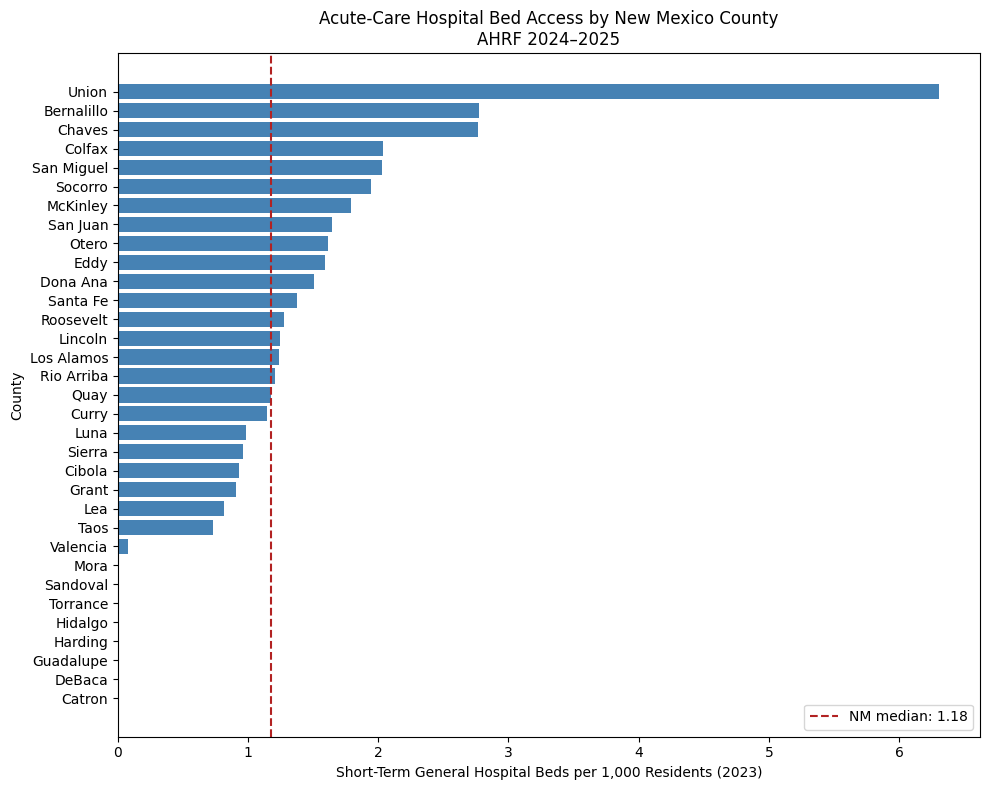

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(nm_view['cnty_name'], nm_view['stgh_beds_per_1k'], color='steelblue')
ax.set_xlabel('Short-Term General Hospital Beds per 1,000 Residents (2023)')
ax.set_ylabel('County')
ax.set_title('Acute-Care Hospital Bed Access by New Mexico County\nAHRF 2024–2025')
ax.axvline(nm_view['stgh_beds_per_1k'].median(), color='firebrick',
           linestyle='--', label=f"NM median: {nm_view['stgh_beds_per_1k'].median():.2f}")
ax.legend()
plt.tight_layout()
plt.show()


### Plotly version

In [ ]:
import plotly.express as px

fig = px.bar(
    nm_view,
    x='stgh_beds_per_1k',
    y='cnty_name',
    orientation='h',
    labels={'stgh_beds_per_1k': 'Short-Term General Hospital Beds per 1,000 Residents (2023)',
            'cnty_name': 'County'},
    title='Acute-Care Hospital Bed Access by New Mexico County — AHRF 2024–2025',
)
fig.add_vline(x=nm_view['stgh_beds_per_1k'].median(), line_dash='dash', line_color='firebrick',
              annotation_text=f"NM median: {nm_view['stgh_beds_per_1k'].median():.2f}")
fig.update_layout(height=800, yaxis=dict(categoryorder='total ascending'))
fig.show()

# Confusion Matrix ???
yo identify true psotitive and true negeative, sensitivity is the true positive rate to actual postive TP / (TP + FN) [Sensitivity Definition](https://www.datacamp.com/tutorial/sensitivity-specificity-complete-guide)is a recall method measuring corect possitives.   Sensitivity/recall = TP/(TP+FN) (classifiers only, confusion-matrix territory)